# Polynomial Regression

In [1]:
import pandas as pd
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = {
    'Level': list(range(1, 102)),
    'Salary': [
        30000, 32000, 34000, 36000, 38000, 41000, 44000, 48000, 52000, 57000,
        63000, 70000, 78000, 87000, 97000, 108000, 120000, 133000, 147000, 162000,
        178000, 195000, 213000, 232000, 252000, 273000, 295000, 318000, 342000, 367000,
        393000, 420000, 448000, 477000, 507000, 538000, 570000, 603000, 637000, 672000,
        708000, 745000, 783000, 822000, 862000, 903000, 945000, 988000, 1032000, 1077000,
        1123000, 1170000, 1218000, 1267000, 1317000, 1368000, 1420000, 1473000, 1527000, 1582000,
        1638000, 1695000, 1753000, 1812000, 1872000, 1933000, 1995000, 2058000, 2122000, 2187000,
        2253000, 2320000, 2388000, 2457000, 2527000, 2598000, 2670000, 2743000, 2817000, 2892000,
        2968000, 3045000, 3123000, 3202000, 3282000, 3363000, 3445000, 3528000, 3612000, 3697000,
        3783000, 3870000, 3958000, 4047000, 4137000, 4228000, 4320000, 4413000, 4507000, 4602000,
        4829000
    ]
}
df = pd.DataFrame(data)
df.head(3)

,Level,Salary
0,1,30000
1,2,32000
2,3,34000


In [3]:
# Here We can show both of them are highly co-releted
df.corr()

,Level,Salary
Level,1.000000,0.962668
Salary,0.962668,1.000000


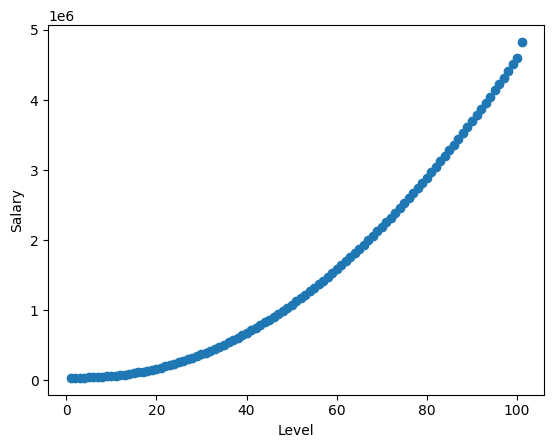

In [4]:
plt.scatter(df['Level'], df['Salary'])
plt.xlabel('Level')
plt.ylabel('Salary')
plt.show()

In [5]:
x = df[['Level']]
y = df['Salary']

In [6]:
# Here we are Convert our data to PolynomialFeatures

In [7]:
from sklearn.preprocessing import PolynomialFeatures

In [8]:
x.shape

(101, 1)

In [9]:
# if our dataset follow using degree 2 then it's ok and if not then increase value and check again
pf = PolynomialFeatures(degree=2)
pf.fit(x)
new = pf.transform(x)
# degree is 2 then column create 3, if degree 3 column create 4 so on..
new.shape

(101, 3)

In [10]:
# Meaning of each term:
# y  -> Dependent (target) variable
# x1 -> Independent (predictor) variable
# b0 -> Intercept (constant term)
# b1, b2, ..., bn -> Coefficients for each polynomial power
# n  -> Degree of the polynomial

In [11]:
# y = b0 + b1*x1 + b2*(x1**2) + b3*(x1**3) + ... + bn*(x1**n)
# y = 0 + -4262.94032855*x1 + 498.10414106*x2

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
x_train, x_test, y_train, y_test = train_test_split(new, y, test_size=0.25)

In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
lr = LinearRegression()
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
lr.score(x_test, y_test)

0.999697816110916

In [17]:
prd = lr.predict(new)

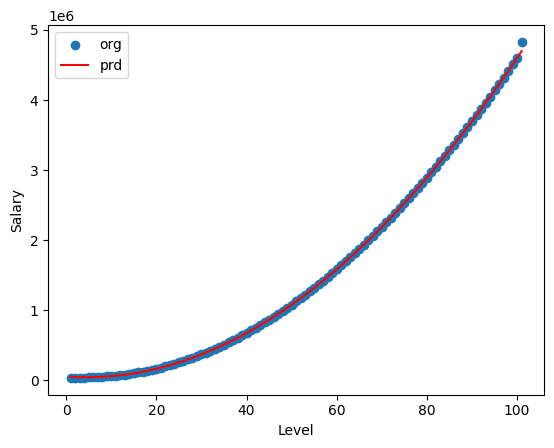

In [18]:
plt.scatter(df['Level'], df['Salary'], label='org')
plt.plot(df['Level'], prd, c='r', label='prd')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [19]:
# ok, now if we want to check our sellery using level then fist we need to transform it

In [20]:
test = pf.transform([[45]])
test

array([[1.000e+00, 4.500e+01, 2.025e+03]])

In [21]:
# So here, we can check at leveal 45 our sellary is 852308
lr.predict(test)

array([862213.70620875])